In [2]:
# Project Customer Segmentation on a shopping mall data using Unsupervised ML algorithm - K-Means Clustering.ipynb

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# https://raw.githubusercontent.com/ingledarshan/upGrad_Darshan/refs/heads/main/Mall_Customers.csv

df = pd.read_csv('https://raw.githubusercontent.com/ingledarshan/upGrad_Darshan/refs/heads/main/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
# Lets understand the dataset's columns: 'CustomerID', 'Gender', 'Age', 'Annual Income (k$)','Spending Score (1-100)'

# 1. CustomerID - Unique ID assigned to each customer (not useful for clustering)
# 2. Gender - Gender of the customer (categorical variable)
# 3. Age - Age of the customer (numerical variable)
# 4. Annual Income (k$) - Annual income of the customer in thousands of dollars (numerical variable)
# 5. Spending Score (1-100) - A score assigned to the customer based on their spending behavior (numerical variable)

In [7]:
df.info() # info() - Provides a concise summary of the DataFrame, including the number of non-null entries, data types of each column, and memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.describe() # describe() - Generates descriptive statistics of the DataFrame, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum values for each numerical column.

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
# Lets groupby Gender and see the mean of Age, Annual Income and Spending Score for each gender
df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [10]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.iloc[:, [3,4]]
# Filter out all the rows of the 3rd and 4th columns (Annual Income and Spending Score) and store it in a variable called X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [12]:
df.iloc[:, [3,4]].values

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [13]:
X = df.iloc[:, [3,4]].values
print(type(X))
X[:10]

<class 'numpy.ndarray'>


array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40],
       [17, 76],
       [18,  6],
       [18, 94],
       [19,  3],
       [19, 72]])

In [14]:
X1 = df.iloc[:, [3,4]]
print(type(X1))
X1.head()

<class 'pandas.core.frame.DataFrame'>


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


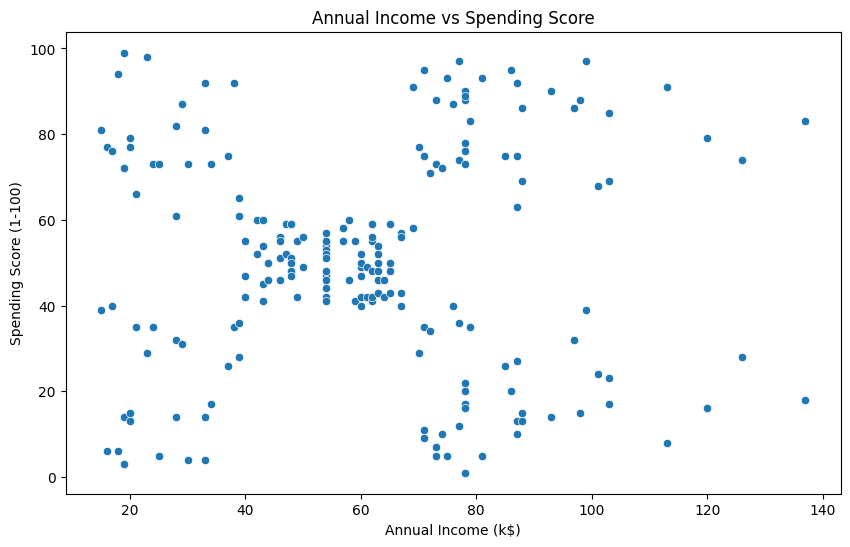

In [15]:
# Lets visualize the X - Annual Income and Spending Score using a scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.show()

In [16]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Hopkins Statistics:
The Hopkins statistic, is a statistic which gives a value which indicates the cluster tendency, in other words: how well the data can be clustered.

- If the value is between {0.01, ...,0.3}, the data is regularly spaced.

- If the value is around 0.5, it is random.

- If the value is between {0.7, ..., 0.99}, it has a high tendency to cluster.

In [17]:
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
import numpy as np
from math import isnan
 
def hopkins(X): # type(X) is DataFrame
    d = X.shape[1]
    #d = len(vars) # columns
    n = len(X) # rows
    m = int(0.1 * n) 
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)
 
    rand_X = sample(range(0, n, 1), m)
 
    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
 
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0
 
    return H

In [18]:
hopkins(X1)

np.float64(0.6853599517924165)

In [19]:
hopkins(X1)

np.float64(0.762590567281531)

In [20]:
hopkins(X1)

np.float64(0.8035016361352075)

In [21]:
hopkins(X1)

np.float64(0.7879610771113397)

In [22]:
# Why is the Hopkins statistic value giving different values on each run? 
# The Hopkins statistic is a measure of the clustering tendency of a dataset. It is calculated by comparing the distances between randomly generated points and the nearest neighbors in the dataset. Since the random points are generated differently each time you run the function, the Hopkins statistic can vary with each execution. This variability is expected and indicates that the clustering tendency of the dataset may not be consistent across different random samples.

# Lets run the Hopkins statistic multiple times (1000 times) and see how many times it is above 0.7
hopkins_values = []
for i in range(1000):
    hopkins_values.append(hopkins(X1))

count_above_0_7 = sum(1 for value in hopkins_values if value > 0.7)
print(f"Number of times the Hopkins statistic is above 0.7: {count_above_0_7} out of 1000 runs")

Number of times the Hopkins statistic is above 0.7: 930 out of 1000 runs


In [23]:
# Lets add tqdm to the above code to see the progress of the loop

# What is tqdm?
# tqdm is a Python library that provides a fast, extensible progress bar for loops and other iterable objects. It allows you to visualize the progress of your code execution, making it easier to track how long a loop is taking to complete. You can use tqdm to wrap around any iterable, and it will display a progress bar in the console, showing the percentage of completion, elapsed time, and estimated time remaining for the loop to finish. This can be particularly useful when running long loops or processing large datasets, as it provides a visual indication of how much work has been done and how much is left to do.
# Full form of tqdm is "taqaddum" in Arabic, which means "progress". It is a popular library for adding progress bars to Python code, especially in data processing and machine learning tasks.

# Install tqdm if you don't have it already
# !pip install tqdm

from tqdm import tqdm
hopkins_values = []
for i in tqdm(range(1000)):
    hopkins_values.append(hopkins(X1))

count_above_0_7 = sum(1 for value in hopkins_values if value > 0.7)
print(f"Number of times the Hopkins statistic is above 0.7: {count_above_0_7} out of 1000 runs")

100%|██████████| 1000/1000 [00:19<00:00, 50.89it/s]

Number of times the Hopkins statistic is above 0.7: 923 out of 1000 runs


[2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1]
[[57.97692308 53.86923077]
 [90.53488372 25.13953488]
 [25.25925926 72.44444444]]


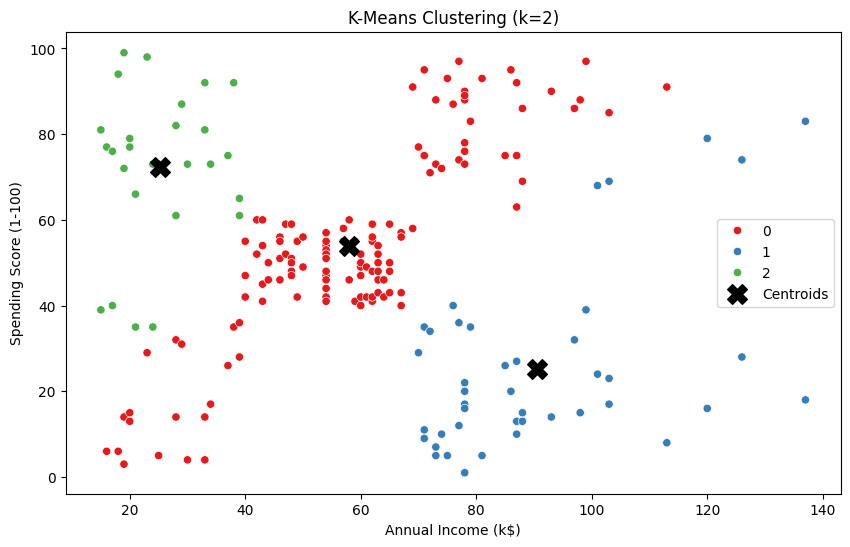

In [24]:
# Now, we will perform K-Means Clustering on the dataset. We will use the 'Annual Income (k$)' and 'Spending Score (1-100)' columns for clustering.

# Lets consider the number of clusters to be 2
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(X)

# Get the cluster labels for each data point
labels = kmeans.labels_
print(labels)

# Get the cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Lets visualize the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=2)')
plt.legend()
plt.show()

In [25]:
centers

array([[57.97692308, 53.86923077],
       [90.53488372, 25.13953488],
       [25.25925926, 72.44444444]])

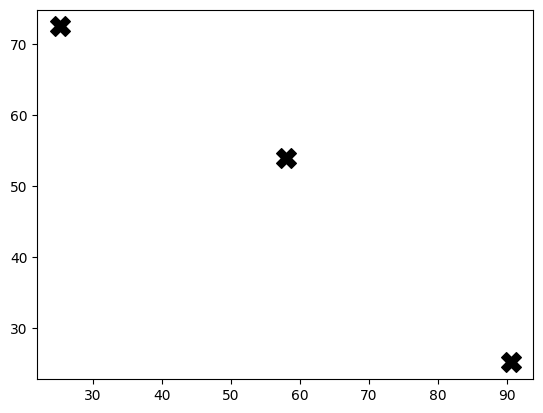

In [26]:
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200, label='Centroids')
plt.show()

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
[[87.         18.63157895]
 [86.53846154 82.12820513]
 [44.15447154 49.82926829]]


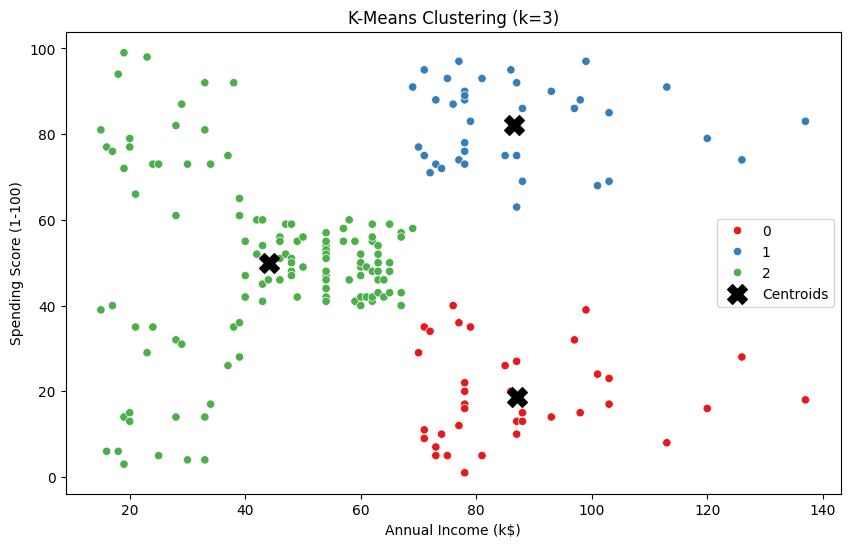

In [27]:
# Now, we will perform K-Means Clustering on the dataset. We will use the 'Annual Income (k$)' and 'Spending Score (1-100)' columns for clustering.

# Lets consider the number of clusters to be 3
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Get the cluster labels for each data point
labels = kmeans.labels_
print(labels)

# Get the cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Lets visualize the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=3)')
plt.legend()
plt.show()

[0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
[[48.16831683 43.3960396 ]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [87.         18.63157895]]


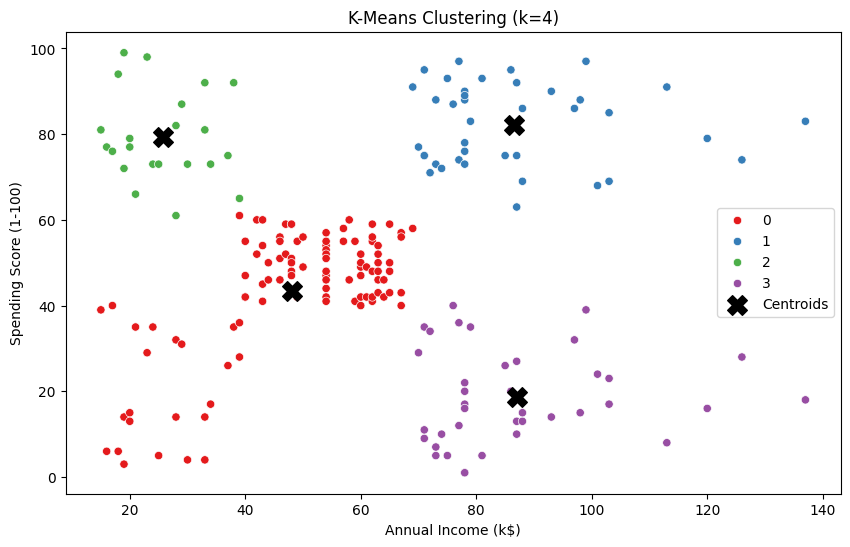

In [28]:
# Now, we will perform K-Means Clustering on the dataset. We will use the 'Annual Income (k$)' and 'Spending Score (1-100)' columns for clustering.

# Lets consider the number of clusters to be 4
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Get the cluster labels for each data point
labels = kmeans.labels_
print(labels)

# Get the cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Lets visualize the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=4)')
plt.legend()
plt.show()

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


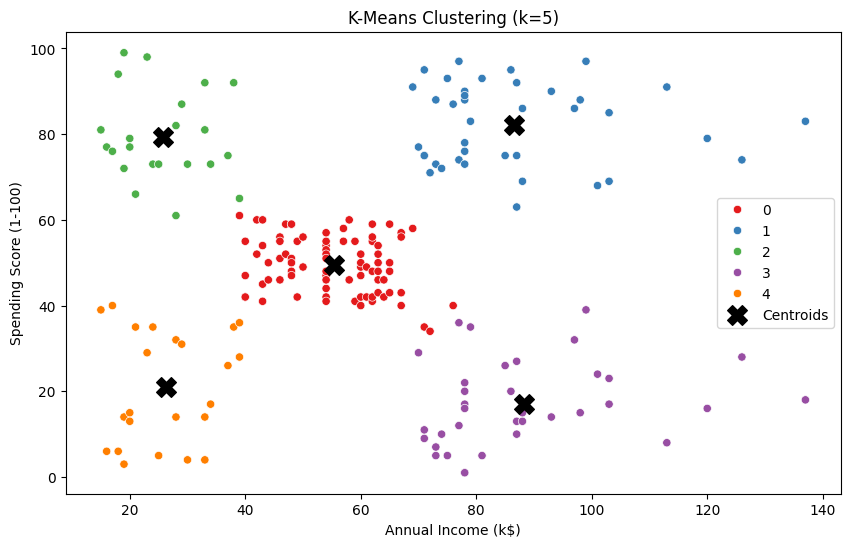

In [29]:
# Now, we will perform K-Means Clustering on the dataset. We will use the 'Annual Income (k$)' and 'Spending Score (1-100)' columns for clustering.

# Lets consider the number of clusters to be 5
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Get the cluster labels for each data point
labels = kmeans.labels_
print(labels)

# Get the cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Lets visualize the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=5)')
plt.legend()
plt.show()

[5 2 4 2 5 2 4 2 4 2 4 2 4 2 4 2 5 2 5 2 5 2 4 2 4 2 5 2 5 2 4 2 4 2 4 2 4
 2 5 2 5 2 5 0 5 2 0 5 5 5 0 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
[[56.05194805 49.85714286]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [24.58333333  9.58333333]
 [31.53333333 35.86666667]]


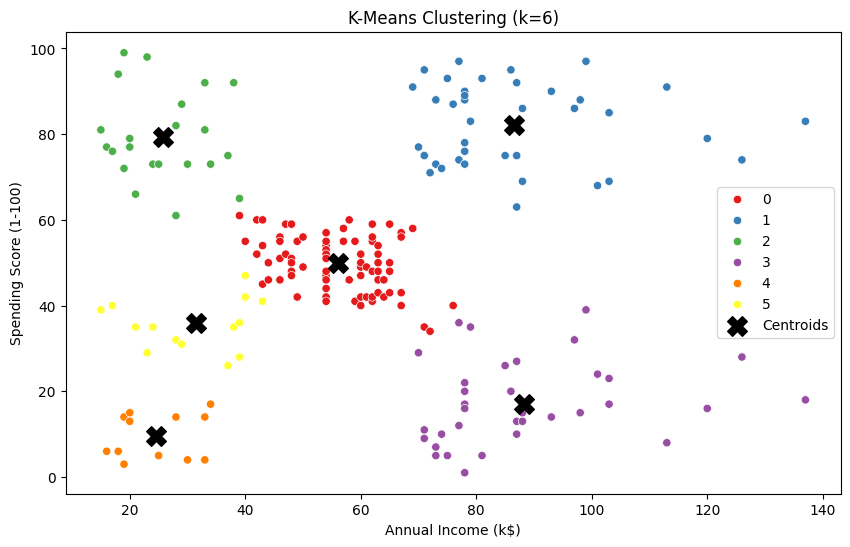

In [30]:
# Now, we will perform K-Means Clustering on the dataset. We will use the 'Annual Income (k$)' and 'Spending Score (1-100)' columns for clustering.

# Lets consider the number of clusters to be 6
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X)

# Get the cluster labels for each data point
labels = kmeans.labels_
print(labels)

# Get the cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Lets visualize the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=6)')
plt.legend()
plt.show()

[5 2 4 2 5 2 4 2 4 2 4 2 4 2 4 2 5 2 5 2 5 2 4 2 4 2 5 2 5 2 4 2 4 2 4 2 4
 2 5 2 5 2 5 0 5 2 0 5 5 5 0 0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 6 3 6 0 6 3 6 3 6 0 6 3 6 3 6 3 6 3 6 0 6 3 6 3 6
 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 6 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
[[ 56.05194805  49.85714286]
 [108.18181818  82.72727273]
 [ 25.72727273  79.36363636]
 [ 88.2         17.11428571]
 [ 24.58333333   9.58333333]
 [ 31.53333333  35.86666667]
 [ 78.03571429  81.89285714]]


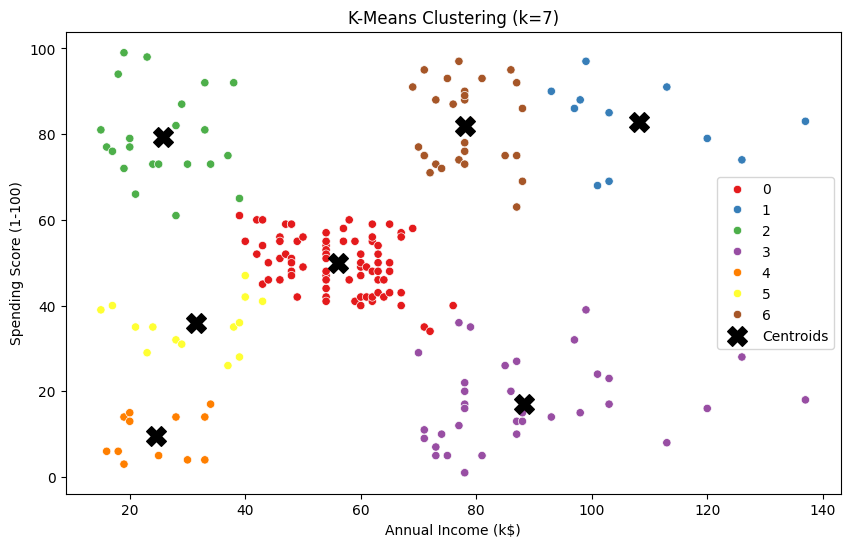

In [31]:
# Now, we will perform K-Means Clustering on the dataset. We will use the 'Annual Income (k$)' and 'Spending Score (1-100)' columns for clustering.

# Lets consider the number of clusters to be 7
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=7, random_state=42)
kmeans.fit(X)

# Get the cluster labels for each data point
labels = kmeans.labels_
print(labels)

# Get the cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Lets visualize the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=7)')
plt.legend()
plt.show()

In [32]:
# Now the question is, which number of clusters is the best? To answer this question, we can use a. The Elbow method or b. The Silhouette score. We will discuss these methods in the next section.

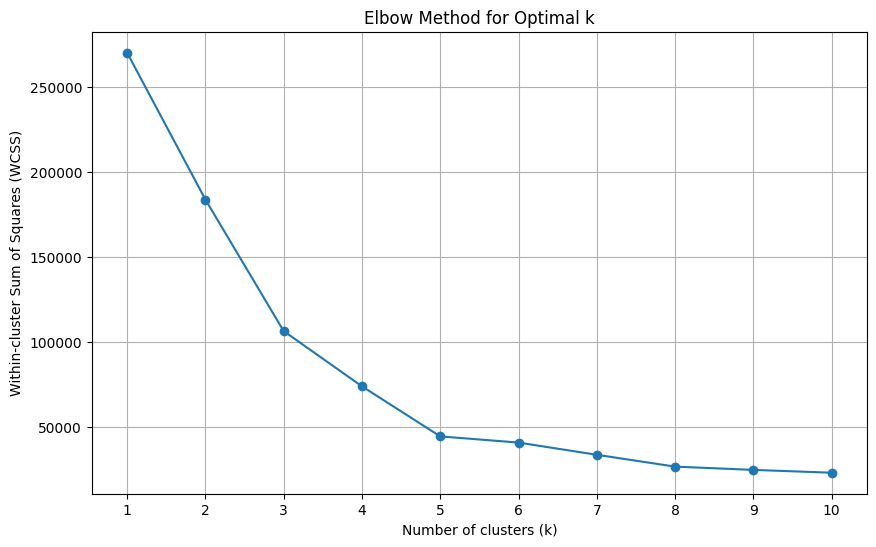

In [33]:
# What is the Elbow method?
# The Elbow method is a technique used to determine the optimal number of clusters in a dataset when using clustering algorithms like K-Means. It involves plotting the within-cluster sum of squares (WCSS) against the number of clusters (k) and looking for an "elbow" point in the graph. The WCSS is a measure of how tightly the data points are clustered around the centroids. As the number of clusters increases, the WCSS decreases, but at some point, the rate of decrease slows down significantly, creating an "elbow" shape in the plot. The optimal number of clusters is often considered to be at the point where the elbow occurs, as it indicates a good balance between having enough clusters to capture the structure of the data and not having too many clusters that may lead to overfitting.

# Lets implement the Elbow method to find the optimal number of clusters for our dataset
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    # What is inertia_ in KMeans?
    # In KMeans, inertia_ is an attribute that represents the within-cluster sum of squares (WCSS). It is a measure of how tightly the data points are clustered around the centroids. The lower the inertia_, the better the clustering, as it indicates that the data points are closer to their respective centroids. When using the Elbow method, we plot the inertia_ values against the number of clusters (k) to identify the optimal number of clusters based on the "elbow" point in the graph.

# Lets plot the Elbow method graph
plt.figure(figsize=(10,6))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.xticks(range(1, 11))
plt.grid()
plt.show()

It is clear from the figure that we should take the number of clusters equal to 5, as the slope of the curve is not steep enough after it.

The K-means clustering algorithm is used to find groups which have not been explicitly labeled in the data. This can be used to confirm business assumptions about what types of groups exist or to identify unknown groups in complex data sets. Once the algorithm has been run and the groups are defined, any new data can be easily assigned to the correct group.

## Silhouette Analysis

$$\text{silhouette score}=\frac{p-q}{max(p,q)}$$

$p$ is the mean distance to the points in the nearest cluster that the data point is not a part of

$q$ is the mean intra-cluster distance to all the points in its own cluster.

* The value of the silhouette score range lies between -1 to 1. 

* A score closer to 1 indicates that the data point is very similar to other data points in the cluster, 

* A score closer to -1 indicates that the data point is not similar to the data points in its cluster.

In [34]:
# Lets apply Silhouette score to find the optimal number of clusters for our dataset
from sklearn.metrics import silhouette_score
silhouette_scores = []
for i in range(2, 15):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X, labels))

In [35]:
silhouette_scores

[0.39564531743995546,
 0.46761358158775435,
 0.4937945814354117,
 0.553931997444648,
 0.5128405328004378,
 0.5017174409749505,
 0.4962769338093321,
 0.45587414130065596,
 0.4426214845978157,
 0.41413838935154096,
 0.3868530059780521,
 0.39183901311789154,
 0.3770223217506244]

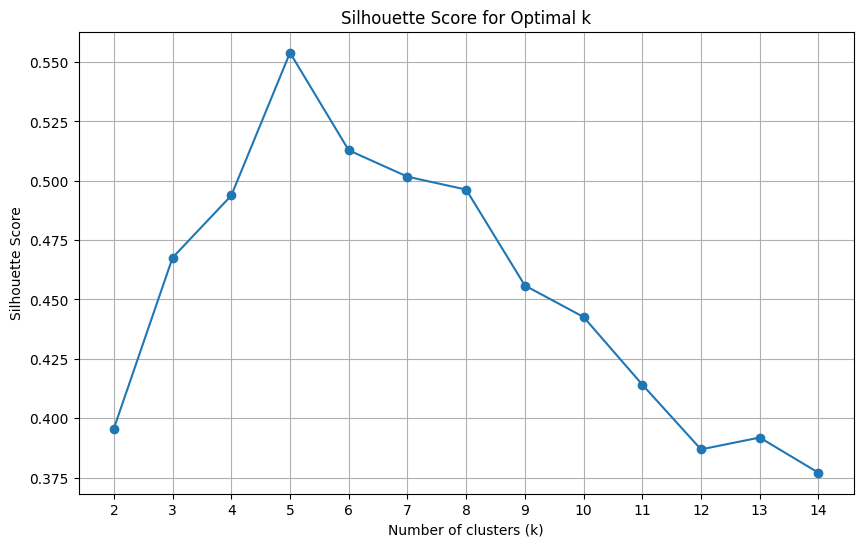

In [36]:
# Lets plot the Silhouette scores for different number of clusters
plt.figure(figsize=(10,6))
plt.plot(range(2, 15), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(range(2, 15))
plt.grid()
plt.show()

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


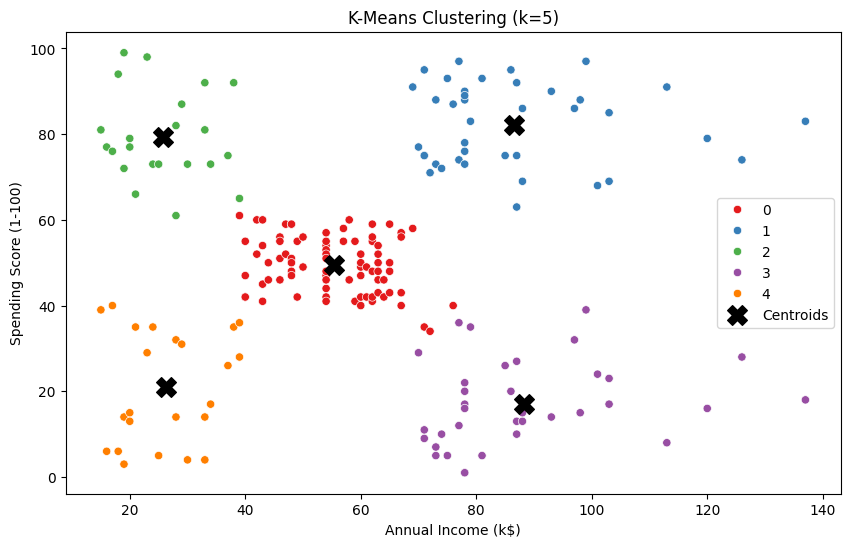

In [37]:
# Now, we will perform K-Means Clustering on the dataset. We will use the 'Annual Income (k$)' and 'Spending Score (1-100)' columns for clustering.

# Lets consider the number of clusters to be 5
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Get the cluster labels for each data point
labels = kmeans.labels_
print(labels)

# Get the cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Lets visualize the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1')
plt.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=5)')
plt.legend()
plt.show()

__Analyzing the Results__

We can see that the mall customers can be broadly __grouped into 5 groups__ based on their purchases made in the mall. 

__In cluster 4(yellow colored) we can see people have low annual income and low spending scores, this is quite reasonable as people having low salaries prefer to buy less__, in fact, these are the wise people who know how to spend and save money. The shops/mall will be least interested in people belonging to this cluster.

__In cluster 2(blue colored) we can see that people have low income but higher spending scores, these are those people who for some reason love to buy products more often even though they have a low income.__ Maybe it’s because these people are more than satisfied with the mall services. The shops/malls might not target these people that effectively but still will not lose them.

__In cluster 5(pink colored) we see that people have average income and an average spending score, these people again will not be the prime targets of the shops or mall,__ but again they will be considered and other data analysis techniques may be used to increase their spending score.

__In cluster 1(red-colored) we see that people have high income and high spending scores, this is the ideal case for the mall or shops as these people are the prime sources of profit.__ These people might be the regular customers of the mall and are convinced by the mall’s facilities.

__In cluster 3(green colored) we see that people have high income but low spending scores, this is interesting. Maybe these are the people who are unsatisfied or unhappy by the mall’s services.__ These can be the prime targets of the mall, as they have the potential to spend money. So, the mall authorities will try to add new facilities so that they can attract these people and can meet their needs.

__Advantages__

1) Fast, robust and easier to understand.

2) Relatively efficient: O(tknd), where n is # objects, k is # clusters, d is # dimension of each object, and t is # iterations. Normally, k, t, d << n.

3) Gives best result when data set are distinct or well separated from each other.

__Benefits of customer segmentation__

By enabling companies to target specific groups of customers, a customer segmentation model allows for the effective allocation of marketing resources and the maximization of cross- and up-selling opportunities.

When a group of customers is sent personalized messages as part of a marketing mix that is designed around their needs, it's easier for companies to send those customers special offers meant to encourage them to buy more products. Customer segmentation can also improve customer service and assist in customer loyalty and retention.

As a by-product of its personalized nature, marketing materials sent out using customer segmentation tend to be more valued and appreciated by the customer who receives them as opposed to impersonal brand messaging that doesn't acknowledge purchase history or any kind of customer relationship.

Other benefits of customer segmentation include staying a step ahead of competitors in specific sections of the market and identifying new products that existing or potential customers could be interested in or improving products to meet customer expectations.

In [38]:
X1.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [39]:
labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [40]:
# Lets attach labels to the original dataframe and see the mean of Age, Annual Income and Spending Score for each cluster
X1['Cluster_KMeans'] = labels
X1.head()

C:\Users\Jagdish singh\AppData\Local\Temp\ipykernel_24572\3301724660.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X1['Cluster_KMeans'] = labels


,Annual Income (k$),Spending Score (1-100),Cluster_KMeans
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


In [41]:
X1.columns

Index(['Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_KMeans'], dtype='object')

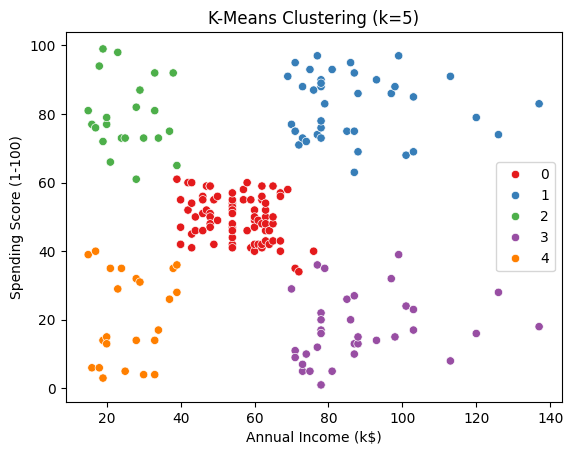

In [42]:
sns.scatterplot(x=X1.iloc[:,0], y=X1.iloc[:,1],hue=X1.iloc[:,2], palette='Set1')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=5)')
plt.legend()
plt.show()

In [43]:
X1['Cluster_KMeans_Label'] = X1['Cluster_KMeans'].replace({
0:"MIMS",
1:"HIHS",
2:"LIHS",
3:"HILS",
4:"LILS"
})

X1.head()

C:\Users\Jagdish singh\AppData\Local\Temp\ipykernel_24572\4210523167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X1['Cluster_KMeans_Label'] = X1['Cluster_KMeans'].replace({


,Annual Income (k$),Spending Score (1-100),Cluster_KMeans,Cluster_KMeans_Label
0,15,39,4,LILS
1,15,81,2,LIHS
2,16,6,4,LILS
3,16,77,2,LIHS
4,17,40,4,LILS


In [44]:
# 0 - MIMS
# 1 - HIHS
# 2 - LIHS
# 3 - HILS
# 4 - LILS

# Create new column using dictionary
new_data = { 0:"MIMS", 1:"HIHS", 2:"LIHS", 3:"HILS", 4:"LILS" }
X1['Cluster_KMeans_Label'] = X1['Cluster_KMeans'].map(new_data)
X1.head()

C:\Users\Jagdish singh\AppData\Local\Temp\ipykernel_24572\2908499482.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X1['Cluster_KMeans_Label'] = X1['Cluster_KMeans'].map(new_data)


,Annual Income (k$),Spending Score (1-100),Cluster_KMeans,Cluster_KMeans_Label
0,15,39,4,LILS
1,15,81,2,LIHS
2,16,6,4,LILS
3,16,77,2,LIHS
4,17,40,4,LILS


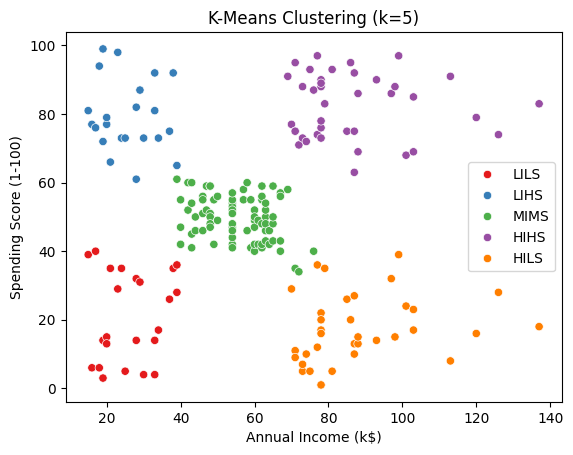

In [45]:
# Lets plot it again
sns.scatterplot(x=X1['Annual Income (k$)'], y=X1['Spending Score (1-100)'], hue=X1['Cluster_KMeans_Label'], palette='Set1')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=5)')
plt.legend()
plt.show()

In [46]:
X1

,Annual Income (k$),Spending Score (1-100),Cluster_KMeans,Cluster_KMeans_Label
0,15,39,4,LILS
1,15,81,2,LIHS
2,16,6,4,LILS
3,16,77,2,LIHS
4,17,40,4,LILS
...,...,...,...,...
195,120,79,1,HIHS
196,126,28,3,HILS
197,126,74,1,HIHS
198,137,18,3,HILS


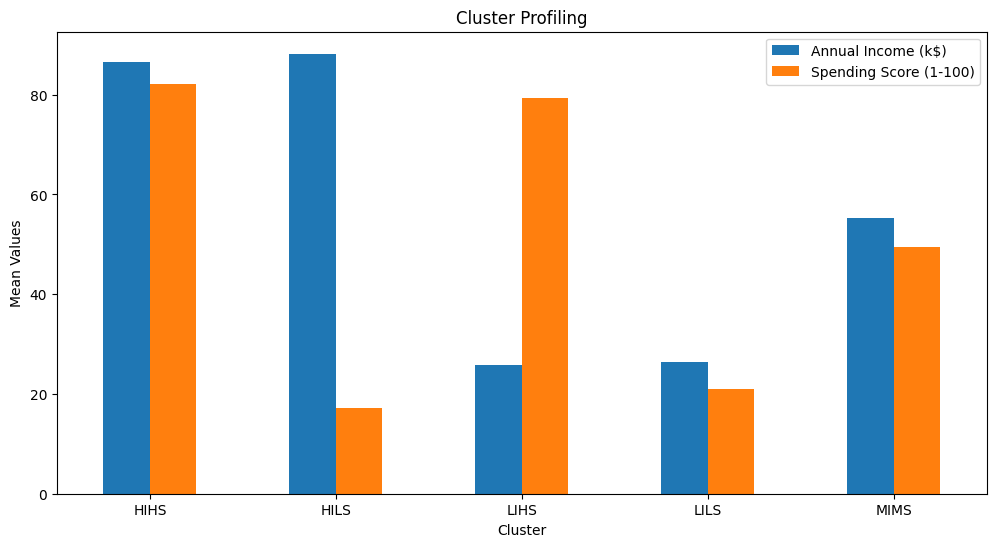

In [47]:
# Cluster Profiling

X1[['Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_KMeans_Label']].groupby('Cluster_KMeans_Label').mean().plot(kind='bar', figsize=(12,6))
plt.title('Cluster Profiling')
plt.xlabel('Cluster')
plt.ylabel('Mean Values')
plt.xticks(rotation=0)
plt.show()

In [48]:
cluster_of_interest = X1[X1['Cluster_KMeans_Label'] == 'HILS']
cluster_of_interest.head()

,Annual Income (k$),Spending Score (1-100),Cluster_KMeans,Cluster_KMeans_Label
124,70,29,3,HILS
128,71,11,3,HILS
130,71,9,3,HILS
134,73,5,3,HILS
136,73,7,3,HILS


In [49]:
X2 = X1.drop(["Cluster_KMeans_Label"], axis=1)
X2.head()

,Annual Income (k$),Spending Score (1-100),Cluster_KMeans
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


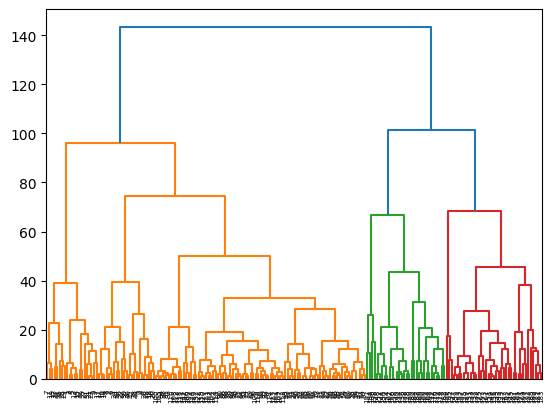

In [50]:
# Hierarchical Clustering

from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

mergings = linkage(X2, method="complete", metric="euclidean")
# linkage() - Performs hierarchical/agglomerative clustering. It takes the input data and computes the distances between data points to create a hierarchical cluster tree (dendrogram). The method parameter specifies the linkage criterion (e.g., "complete", "single", "average"), and the metric parameter specifies the distance metric (e.g., "euclidean", "manhattan").
# method="complete" - This specifies that the distance between clusters should be calculated using the complete linkage method, which considers the maximum distance between points in different clusters.
# metric="euclidean" - This specifies that the distance metric to be used is the Euclidean distance, which is the straight-line distance between two points in? a multi-dimensional space.
dendrogram(mergings)
plt.show()

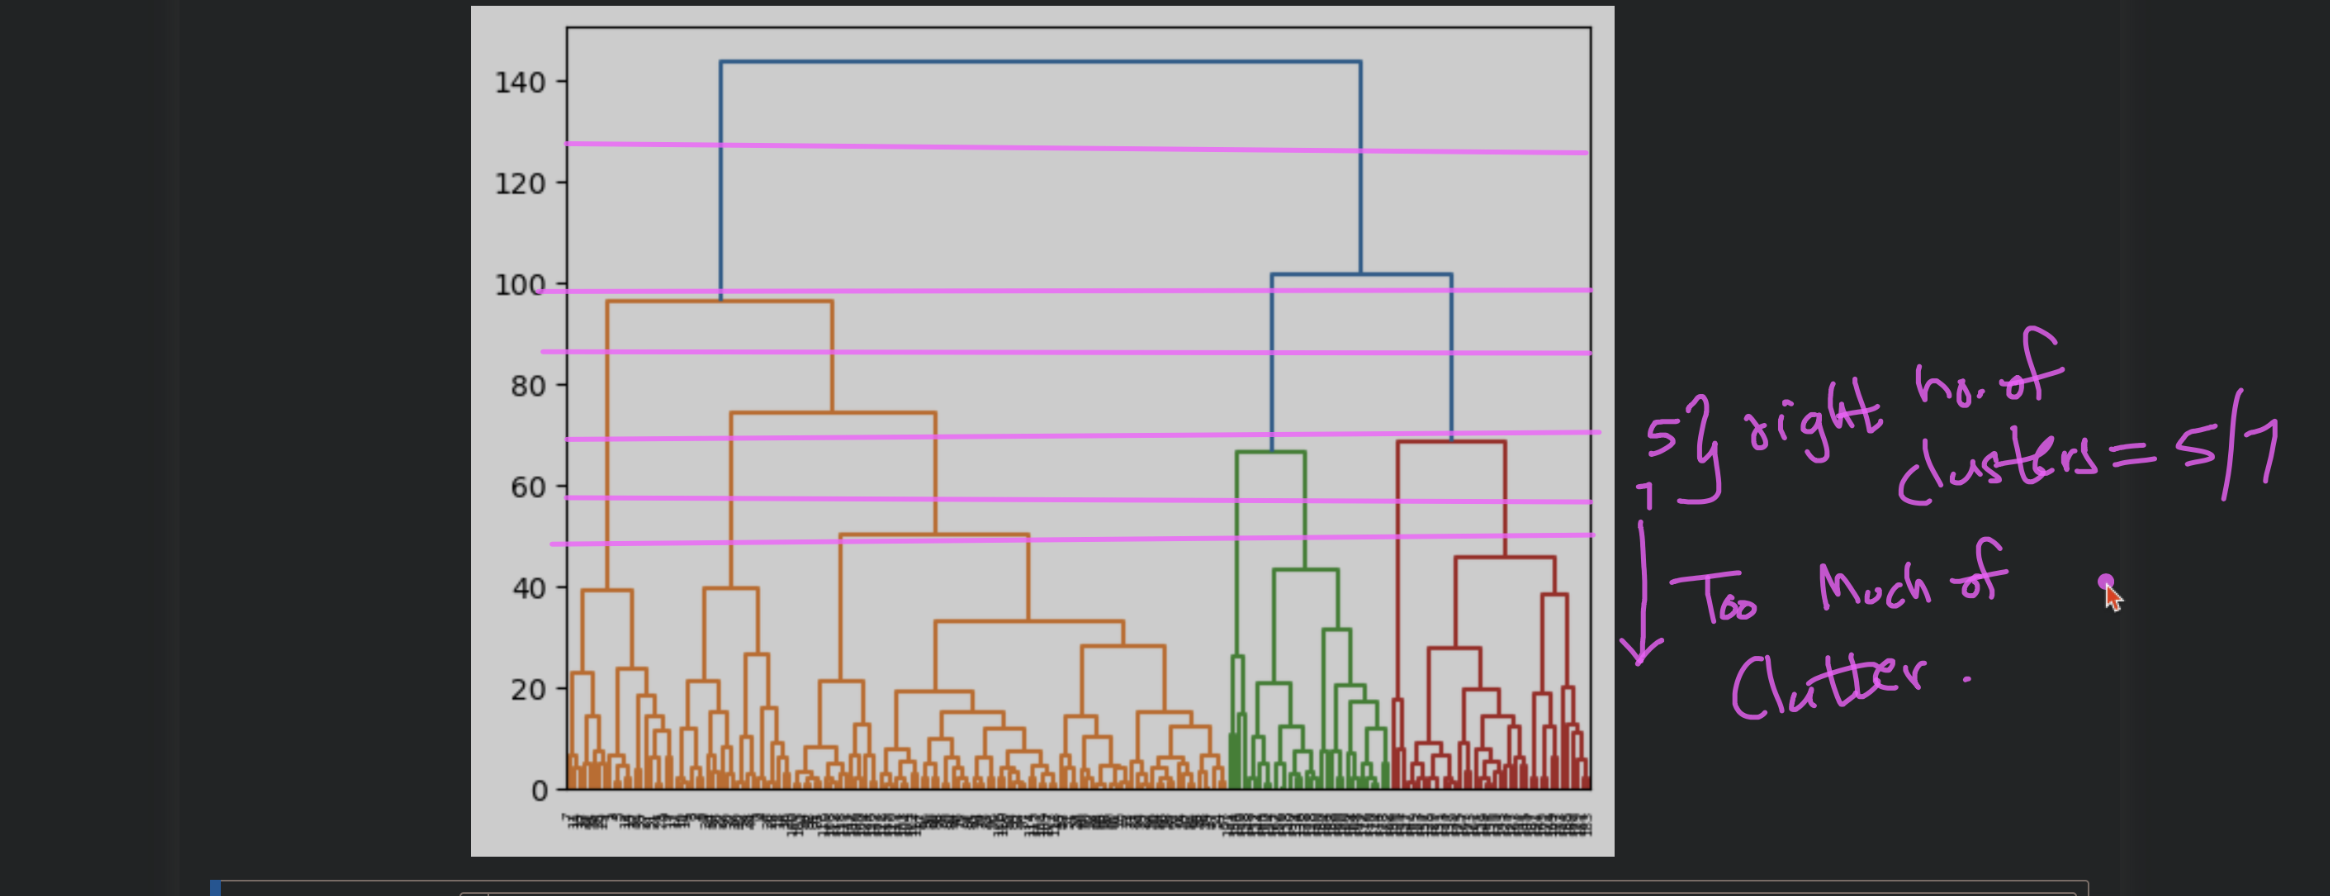

In [51]:
cluster_labels_HC = cut_tree(mergings, n_clusters=5).reshape(-1,)
cluster_labels_HC

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 3, 4, 3, 4, 3,
       2, 3, 4, 3, 4, 3, 4, 3, 4, 3, 2, 3, 4, 3, 2, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 2, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3])

In [52]:
X1.head()

,Annual Income (k$),Spending Score (1-100),Cluster_KMeans,Cluster_KMeans_Label
0,15,39,4,LILS
1,15,81,2,LIHS
2,16,6,4,LILS
3,16,77,2,LIHS
4,17,40,4,LILS


In [53]:
X1["cluster_labels_HC"] = cluster_labels_HC
X1.head()

,Annual Income (k$),Spending Score (1-100),Cluster_KMeans,Cluster_KMeans_Label,cluster_labels_HC
0,15,39,4,LILS,0
1,15,81,2,LIHS,1
2,16,6,4,LILS,0
3,16,77,2,LIHS,1
4,17,40,4,LILS,0


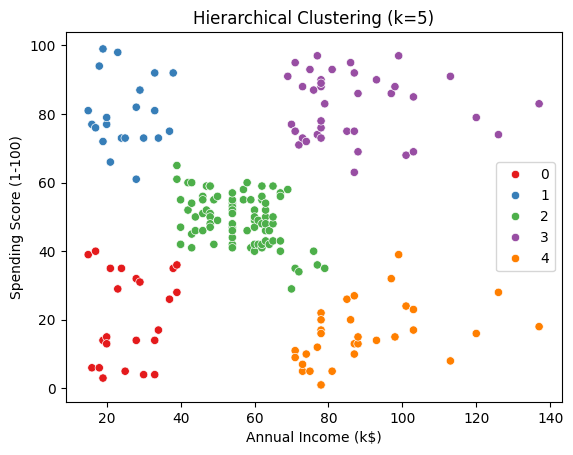

In [54]:
# Lets plot the scatter plot for hierarchical clustering using cluster_labels_HC
sns.scatterplot(x=X1['Annual Income (k$)'], y=X1['Spending Score (1-100)'], hue=X1['cluster_labels_HC'], palette='Set1')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hierarchical Clustering (k=5)')
plt.legend()
plt.show()

In [55]:
# 0=LILS
# 1=LIHS
# 2=MIMS
# 3=HIHS
# 4=HILS

# Create new column using dictionary
new_data = { 0:"LILS", 1:"LIHS", 2:"MIMS", 3:"HIHS", 4:"HILS" }
X1['Cluster_HC_Label'] = X1['cluster_labels_HC'].map(new_data)
X1.head()

,Annual Income (k$),Spending Score (1-100),Cluster_KMeans,Cluster_KMeans_Label,cluster_labels_HC,Cluster_HC_Label
0,15,39,4,LILS,0,LILS
1,15,81,2,LIHS,1,LIHS
2,16,6,4,LILS,0,LILS
3,16,77,2,LIHS,1,LIHS
4,17,40,4,LILS,0,LILS


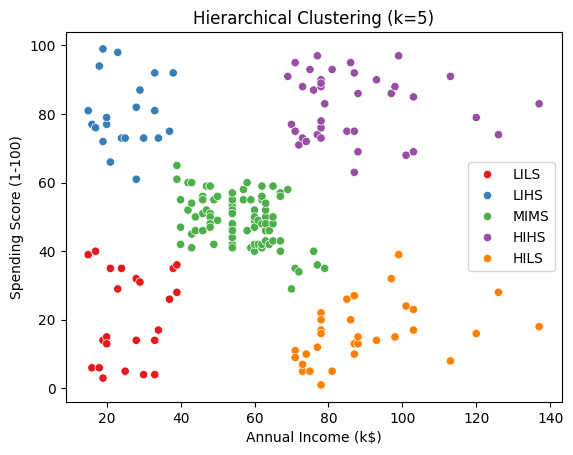

In [56]:
sns.scatterplot(x=X1['Annual Income (k$)'], y=X1['Spending Score (1-100)'], hue=X1['Cluster_HC_Label'], palette='Set1')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hierarchical Clustering (k=5)')
plt.legend()
plt.show()

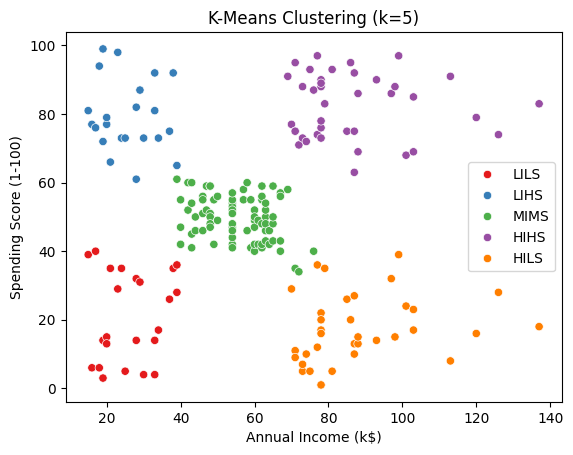

In [57]:
# Lets plot it again
sns.scatterplot(x=X1['Annual Income (k$)'], y=X1['Spending Score (1-100)'], hue=X1['Cluster_KMeans_Label'], palette='Set1')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering (k=5)')
plt.legend()
plt.show()

In [58]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [59]:
# As a homework, you can try to repeat the entire notebook using Age, Annual Income (k$) and Spending Score (1-100) columns.

# Happy Learning